# Causal Outlier Propagation — An Approach to Structurally-Informed Data Degradation

This notebook explains the **Causal Outlier Propagation Generator**, a new addition to Badgers that uses causal graphical models (DAGs) as input scaffolding to produce structurally-informed outliers.

Instead of treating all columns independently, this generator respects the causal relationships between variables: an outlier injected into a root-cause variable cascades to its downstream effects, producing more realistic and semantically meaningful anomalies.

---

## Table of Contents

1. [Motivation: Why Causal Graphs?](#motivation)
2. [Core Concepts: DAGs as Scaffolding](#core-concepts)
3. [The Algorithm: Forward-Pass Propagation](#algorithm)
4. [Graph Conventions: Nodes, Columns, and Mapping](#conventions)
5. [API Walkthrough](#api)
6. [Topology Examples: Chain, Fork, Collider, Diamond](#topologies)
7. [Error Handling and Edge Cases](#errors)
8. [Testing Strategy](#testing)

## 1. Motivation: Why Causal Graphs? <a id="motivation"></a>

### The Problem with Independent Outliers

Traditional outlier generators in Badgers (z-score, hypersphere, hypercube, histogram) treat each column independently. They add noise or extreme values to individual features without considering how those features relate to each other.

In real-world systems, variables are connected by causal relationships:

```mermaid
graph LR
    Temperature --> IceCreamSales
    Temperature --> CrimeRate
    IceCreamSales --> Revenue
```

An extreme temperature value should cascade: it affects ice cream sales, which in turn affects revenue. An independent outlier generator might spike revenue without touching temperature or sales — a physically impossible scenario.

### The Solution: Causal Scaffolding

By providing a **causal graph** (a directed acyclic graph, or DAG) as input, the generator can:

1. **Inject** an outlier at a user-specified root-cause node
2. **Propagate** the perturbation to all descendant nodes along causal edges
3. **Preserve** the causal structure — only variables downstream of the perturbed node are affected

This produces **structurally consistent** outliers that test whether anomaly detectors catch semantically meaningful anomalies, not just marginal-statistic deviations.

## 2. Core Concepts: DAGs as Scaffolding <a id="core-concepts"></a>

### What is a DAG?

A **Directed Acyclic Graph (DAG)** is a graph with:
- **Directed edges** (arrows): $A \rightarrow B$ means "A causes B"
- **No cycles**: you can't follow arrows and return to where you started

We use `networkx.DiGraph` as the representation — it's already a Badgers dependency and the lingua franca in the Python causal ecosystem.

### Key Terminology

| Term | Definition | Example in $X \rightarrow Y \rightarrow Z$ |
|------|-----------|------------------------------------------|
| **Parent** | Direct cause of a node | `parents(Y) = {X}` |
| **Child** | Direct effect of a node | `children(X) = {Y}` |
| **Ancestor** | Any upstream cause (direct or indirect) | `ancestors(Z) = {X, Y}` |
| **Descendant** | Any downstream effect (direct or indirect) | `descendants(X) = {Y, Z}` |
| **Root node** | Node with no parents (in-degree 0) | `X` |
| **Leaf node** | Node with no children (out-degree 0) | `Z` |
| **Topological order** | Linear ordering where parents appear before children | `[X, Y, Z]` |

### The `badgers.core.causal_graph` Module

A new lightweight utility module provides stateless functions for working with causal DAGs:

```python
from badgers.core.causal_graph import (
    validate_dag,        # Raises ValueError if not a DAG
    topological_order,   # Returns nodes in topological order
    get_parents,         # Immediate predecessors
    get_descendants,     # All reachable nodes
    get_ancestors,       # All nodes that can reach this node
    get_root_nodes,      # Nodes with in-degree 0
    get_leaf_nodes,      # Nodes with out-degree 0
    node_to_index,       # Maps a node (str or int) to a column index
)
```

All functions are stateless, take a `nx.DiGraph` as the first argument, and return plain Python collections.

## 3. The Algorithm: do()-Style Intervention <a id="algorithm"></a>

The generator implements a **do()-style intervention** (inspired by Pearl's do-calculus):
incoming edges to perturbation nodes are severed, ancestors are sampled from
their natural distributions, perturbation nodes are set directly to outlier
values, and only descendants are computed via forward pass.

### Step 1: Validate the DAG

The input graph is checked for cycles using `validate_dag()`. If a cycle is
detected, a `ValueError` is raised immediately.

### Step 2: Topological Sort

Nodes are ordered so that every parent appears before its children. This
ordering is used for both coefficient fitting and forward-pass propagation.

### Step 3: Fit Linear Coefficients

For each node $v$ with parents $P(v)$, fit a linear regression:

$$X[:, v] \approx \sum_{p \in P(v)} \beta_{p \rightarrow v} \cdot X[:, p]$$

This is done via `np.linalg.lstsq` — ordinary least squares. The coefficients $\beta_{p \rightarrow v}$ capture the estimated linear effect of each parent on the child.

### Step 4: Identify Node Sets

Given the set of perturbation nodes $P$:

- **Descendants** $D$: all nodes reachable from any $p \in P$ (these will be forward-passed)
- **Ancestors** $A$: all nodes that can reach any $p \in P$
- **Exogenous** $E = A \setminus (P \cup D)$: ancestors that are neither perturbed nor descendants (these are sampled from their natural distributions)

### Step 5: Sample Exogenous Nodes

Exogenous nodes are sampled from their observed distributions using a
configurable **within-distribution sampler**. The default is `"normal"` —
sampling from $\mathcal{N}(\mu, \sigma)$ for each column independently.

Alternative within-distribution samplers (`"uniform"`) allow sampling
from different in-distribution shapes. See the [Samplers](#samplers) section below.

### Step 6: Set Perturbation Nodes Directly (do-style)

At each perturbation node, the incoming edges are **severed** — the node's
value is set directly rather than computed from its parents. The values are
sampled using a configurable **out-of-distribution sampler** (default:
`"zscore"`), then a perturbation is added with a random $\pm$ sign per row:

$$\Delta_{p} = \text{outlier\_magnitude} \times \sigma(X[:, p])$$

$$\text{outlier}[k, p] = \text{sample}_{\text{ood}}(p) \pm \Delta_{p}$$

### Step 7: Forward-Pass Only to Descendants

For each descendant node $v \in D$ in topological order, compute its value from
its parents using the fitted linear coefficients, plus residual noise matching
the original data's residual variance:

$$\text{outlier}[k, v] = \sum_{p \in P(v)} \beta_{p \rightarrow v} \cdot \text{outlier}[k, p] + \mathcal{N}(0, \sigma_{\text{residual}})$$

Nodes that are neither perturbed nor descendants are left at zero (they are
not part of the causal pathway from the intervention).

### Step 8: Return

The outlier rows are appended to `X`. `yt` contains `"original"` for each original row and `"outliers"` for each generated outlier row.

### Why do()-style?

The old algorithm sampled all root nodes and forward-passed through the entire
DAG. This had a subtle bug: when perturbing a non-root node (e.g., $Y$ in
$X \rightarrow Y \rightarrow Z$), the forward pass would **overwrite** the
perturbation at $Y$ with the value computed from its parent $X$.

The do()-style intervention fixes this by:
1. Severing incoming edges to perturbation nodes
2. Only forward-passing to descendants (not to the perturbation nodes themselves)
3. Leaving non-ancestor, non-descendant nodes untouched

### Visual Summary

```mermaid
flowchart TD
    A[Input: X, graph, perturbation_nodes] --> B[Validate DAG]
    B --> C[Topological Sort]
    C --> D[Fit Linear Coefficients via lstsq]
    D --> E[Identify Exogenous / Perturbed / Descendant sets]
    E --> F[Sample Exogenous Nodes via Within-Distribution Sampler]
    F --> G[Set Perturbation Nodes via Out-of-Distribution Sampler ± Magnitude]
    G --> H[Forward-Pass Only to Descendants]
    H --> I[Append Outliers to X, Return Xt, yt]
```

## 4. Graph Conventions: Nodes, Columns, and Mapping <a id="conventions"></a>

The generator needs to know which graph node corresponds to which column in `X`. Two conventions are supported:

### Integer Nodes → Direct Column Mapping

When nodes are integers, they map directly to column indices:

```python
graph = nx.DiGraph()
graph.add_edges_from([(0, 1), (1, 2)])  # Column 0 → Column 1 → Column 2
```

Node `0` = column `0`, node `1` = column `1`, node `2` = column `2`.

### String Nodes → Sorted Alphabetical Mapping

When nodes are strings, they are sorted alphabetically and mapped to `0..d-1`:

```python
graph = nx.DiGraph()
graph.add_edges_from([("X", "Y"), ("Y", "Z")])
```

Node `"X"` = column `0`, node `"Y"` = column `1`, node `"Z"` = column `2`.

### Reserved for Future Use

- **Node attributes**: `"type"` (latent/observed), `"noise_std"`, `"function"` — not used in v1
- **Edge attributes**: `"effect"` (linear/nonlinear), `"weight"` — not used in v1

## 5. API Walkthrough <a id="api"></a>

### Basic Usage

```python
import networkx as nx
import numpy as np
from badgers.generators.tabular_data.outliers.causal import CausalOutlierPropagationGenerator

# 1. Define your causal graph
graph = nx.DiGraph()
graph.add_edges_from([("X", "Y"), ("Y", "Z")])

# 2. Prepare your data (must have columns matching graph nodes)
X = np.random.default_rng(0).normal(size=(100, 3))  # 100 samples, 3 features

# 3. Create the generator
generator = CausalOutlierPropagationGenerator()

# 4. Generate outliers
Xt, yt = generator.generate(
    X, y=None,
    graph=graph,
    perturbation_nodes=["X"],   # Which node(s) to perturb (list)
    outlier_magnitude=3.0,      # How many standard deviations
    n_outliers=5,               # How many outlier rows to generate
)
# Xt = X with outlier rows appended (shape: (105, 3))
# yt = ["original"]*100 + ["outliers"]*5
```

### Parameters

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `graph` | `nx.DiGraph` | **required** | Causal DAG |
| `perturbation_nodes` | `list[int\|str]` | **required** | Node(s) to intervene on (do-style) |
| `outlier_magnitude` | `float` | `3.0` | Number of standard deviations to perturb |
| `n_outliers` | `int` | `10` | Number of outlier rows to generate |
| `within_distribution_sampler` | `WithinDistributionSampler` or `str` | `"normal"` | Sampling strategy for exogenous (ancestor) nodes |
| `out_of_distribution_sampler` | `OutOfDistributionSampler` or `str` | `"zscore"` | Sampling strategy for perturbation nodes |

### Multiple Perturbation Nodes

You can perturb multiple nodes simultaneously — all perturbations are applied
in the same outlier row:

```python
# Perturb both X and Y at once
Xt, yt = generator.generate(
    X, y=None,
    graph=graph,
    perturbation_nodes=["X", "Y"],
    n_outliers=5,
)
```

### Samplers <a id="samplers"></a>

The generator uses **two separate sampler parameters**:

- **`within_distribution_sampler`** — for exogenous (ancestor) nodes that should
  be sampled from their natural distributions. Accepts a string (resolved via
  `create_within_distribution_sampler`) or a `WithinDistributionSampler` instance.
- **`out_of_distribution_sampler`** — for perturbation nodes that should be
  sampled outside the observed distribution. Accepts a string (resolved via
  `create_out_of_distribution_sampler`) or an `OutOfDistributionSampler` instance.

#### Within-Distribution Samplers

| Sampler | Description |
|---------|-------------|
| `"normal"` | Sample from $\mathcal{N}(\mu, \sigma)$ per dimension (default) |
| `"uniform"` | Sample uniformly within $[\min, \max]$ |

#### Out-of-Distribution Samplers

| Sampler | Description | Extra Parameter |
|---------|-------------|----------------|
| `"zscore"` | $\pm(3 + \text{Exponential}(\text{scale})) \times \sigma$ per dimension (default) | `scale` |
| `"hypersphere"` | Points on a hypersphere with radius $\geq 3\sigma$ | `scale` |
| `"uniform"` | Sample uniformly beyond $[\min, \max]$ with expansion | `expansion` |

```python
from badgers.core.sampling import (
    create_within_distribution_sampler,
    create_out_of_distribution_sampler,
    UniformSampler,
    ZScoreSampler,
)

# Option 1: string shorthand
Xt, yt = generator.generate(
    X, y=None,
    graph=graph,
    perturbation_nodes=["X"],
    n_outliers=5,
    within_distribution_sampler="uniform",
    out_of_distribution_sampler="zscore",
)

# Option 2: Sampler instances with custom parameters
Xt, yt = generator.generate(
    X, y=None,
    graph=graph,
    perturbation_nodes=["X"],
    n_outliers=5,
    within_distribution_sampler=UniformSampler(),
    out_of_distribution_sampler=ZScoreSampler(scale=2.0),
)
```

The sampler classes are implemented in `badgers.core.sampling` and can be used
independently of the causal generator.

### Example

Let's trace through a concrete example with $X \xrightarrow{2.0} Y \xrightarrow{0.5} Z$:

In [1]:
import networkx as nx
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

from badgers.generators.tabular_data.outliers.causal import CausalOutlierPropagationGenerator

In [2]:
import badgers
badgers.__version__

'0.0.14'

#### Define graph and generate data

In [3]:
# Create a chain graph: X -> Y -> Z
graph = nx.DiGraph()
graph.add_edges_from([("X", "Y"), ("Y", "Z")])

# Generate data with known linear relationships
rng = default_rng(42)
n_samples = 100

# X is random normal
X = np.zeros((n_samples, 3))
X[:, 0] = rng.normal(0, 1, size=n_samples)                    # X ~ N(0, 1)
X[:, 1] = 2.0 * X[:, 0] + rng.normal(0, 0.1, size=n_samples)  # Y = 2X + noise
X[:, 2] = 0.5 * X[:, 1] + rng.normal(0, 0.1, size=n_samples)  # Z = 0.5Y + noise

#### Plot the Graph

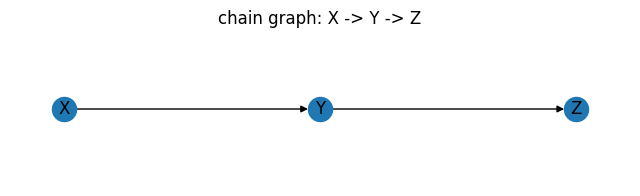

In [4]:
# plot graph
fig, ax = plt.subplots(1, figsize=(8,2))
ax.set_title("chain graph: X -> Y -> Z")
pos = {'X': [-1, 0], 'Y': [0, 0], 'Z': [1., 0]}
nx.draw(graph, pos, ax=ax)
nx.draw_networkx_labels(graph, pos, ax=ax);

#### Show the data

In [5]:
def plot_data(X, y):
    # use y to distinguishg outlies from original data (change markers)
    if y is not None:
        markers = ['.' if label == 'original' else '+' for label in y]
    else:
        markers = '.'
        
    # display the data
    fig, axes = plt.subplots(1,3, sharex=True, sharey=True, figsize=(12,4))
    # seaborn regression plot 1
    # Calculate regression coefficients
    slope, intercept, r_value, p_value, std_err = stats.linregress(X[:,0], X[:,1])
    
    # Create plot and add equation to line label
    sns.regplot(
        x=X[:,0], y=X[:,1],  
        line_kws={'label': f"y = {slope:.2f}x + {intercept:.2f}"},
        scatter_kws={'marker': markers},
        ax=axes[0],
        color='C0'
    )
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")
    axes[0].legend()
    
    # seaborn regression plot 2
    # Calculate regression coefficients
    slope, intercept, r_value, p_value, std_err = stats.linregress(X[:,1], X[:,2])
    
    # Create plot and add equation to line label
    sns.regplot(
        x=X[:,1], y=X[:,2],  
        line_kws={'label': f"z = {slope:.2f}y + {intercept:.2f}"},
        scatter_kws={'marker': markers},
        ax=axes[1],
        color='C2'
    )
    
    axes[1].legend()
    axes[1].set_xlabel("Y")
    axes[1].set_ylabel("Z")
    
    
    # seaborn regression plot 3
    # Calculate regression coefficients
    slope, intercept, r_value, p_value, std_err = stats.linregress(X[:,0], X[:,2])
    
    # Create plot and add equation to line label
    sns.regplot(
        x=X[:,0], y=X[:,2],  
        line_kws={'label': f"z = {slope:.2f}x + {intercept:.2f}"},
        scatter_kws={'marker': markers},
        ax=axes[2],
        color='C1'
    )
    
    axes[2].legend()
    axes[2].set_xlabel("X")
    axes[2].set_ylabel("Z")
    return fig, axes

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: xlabel='X', ylabel='Y'>, <Axes: xlabel='Y', ylabel='Z'>,
        <Axes: xlabel='X', ylabel='Z'>], dtype=object))

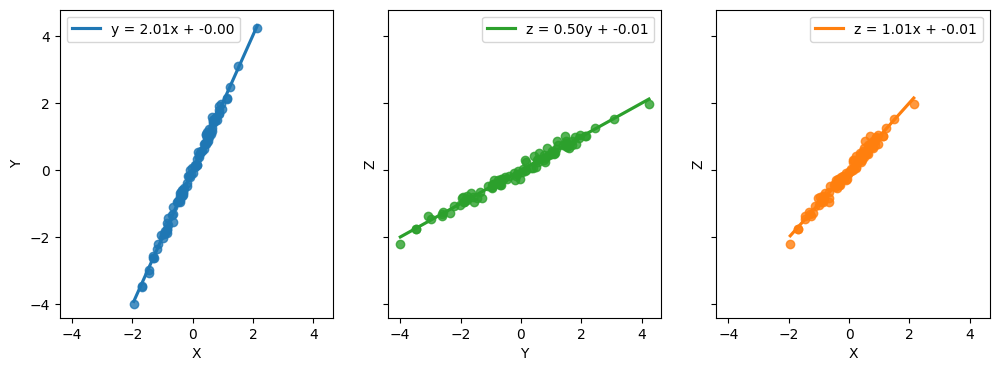

In [6]:
plot_data(X, y=None)

#### Generate multiple outliers

In [7]:
# Generate outliers by perturbing X
generator = CausalOutlierPropagationGenerator(random_generator=rng)

In [8]:
Xt, yt = generator.generate(
    X, y=None,
    graph=graph,
    perturbation_nodes=["X"],
    n_outliers=5,
    outlier_magnitude=10.0,
)

print(f"Original X shape: {X.shape}")
print(f"Transformed Xt shape: {Xt.shape}  (100 original + 5 outliers)")
print(f"yt labels: {list(yt[:3])} ... {list(yt[-3:])}")

Original X shape: (100, 3)
Transformed Xt shape: (105, 3)  (100 original + 5 outliers)
yt labels: [np.str_('original'), np.str_('original'), np.str_('original')] ... [np.str_('outliers'), np.str_('outliers'), np.str_('outliers')]


#### Show the difference between the original and the generated point

In [9]:


# Show the deltas
delta_X = (Xt[len(X):len(Xt), 0] - X[:, 0].mean()).mean()
delta_Y = (Xt[len(X):len(Xt), 1] - X[:, 1].mean()).mean()
delta_Z = (Xt[len(X):len(Xt), 2] - X[:, 2].mean()).mean()



print(f"\nDeltas: ΔX={delta_X:.3f}, ΔY={delta_Y:.3f}, ΔZ={delta_Z:.3f}")
print(f"Ratio ΔY/ΔX ≈ {delta_Y/delta_X:.2f} (expected ~2.0)")
print(f"Ratio ΔZ/ΔY ≈ {delta_Z/delta_Y:.2f} (expected ~0.5)")

# Verify original rows are unchanged
print(f"\nOriginal rows unchanged: {np.allclose(Xt[:len(X)], X)}")


Deltas: ΔX=1.773, ΔY=3.546, ΔZ=1.867
Ratio ΔY/ΔX ≈ 2.00 (expected ~2.0)
Ratio ΔZ/ΔY ≈ 0.53 (expected ~0.5)

Original rows unchanged: True


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: xlabel='X', ylabel='Y'>, <Axes: xlabel='Y', ylabel='Z'>,
        <Axes: xlabel='X', ylabel='Z'>], dtype=object))

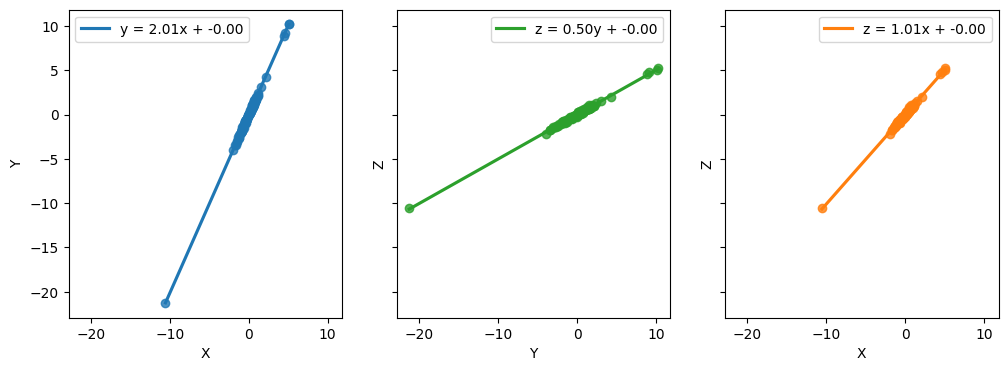

In [10]:
# plot data
plot_data(Xt, y=yt)

### Integration with Badgers Pipeline

The generator works seamlessly with the existing `Pipeline` class:

In [11]:
from badgers.core.pipeline import Pipeline
from badgers.generators.tabular_data.noise import GaussianNoiseGenerator

pipeline = Pipeline(generators={
    'noise': GaussianNoiseGenerator(random_generator=rng),
    'causal_outlier': CausalOutlierPropagationGenerator(random_generator=rng),
})

params = {
    'noise': {'noise_std': 0.25},
    'causal_outlier': {'graph': graph, 'perturbation_nodes': ['X'], 'outlier_magnitude': 3.0},
}

Xt_pipeline, yt_pipeline = pipeline.generate(X=X.copy(), y=None, params=params)

## 6. Topology Examples <a id="topologies"></a>

Different causal structures produce different propagation patterns. Let's explore the four fundamental topologies.

### 6.1 Chain: $X \rightarrow Y \rightarrow Z$

**Perturbing X** affects Y (direct child) and Z (indirect descendant via Y).

**Perturbing Y** affects Z but NOT X (X is upstream, not a descendant).

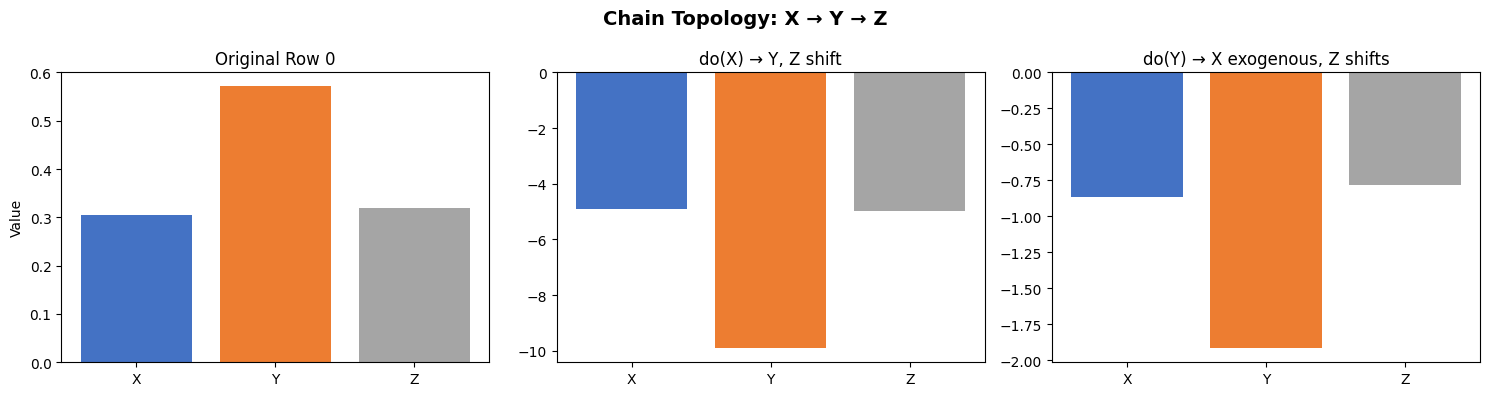

do(X): X changed = True | Y changed = True | Z changed = True
do(Y): X changed = True | Y changed = True | Z changed = True


In [12]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from numpy.random import default_rng

from badgers.generators.tabular_data.outliers.causal import CausalOutlierPropagationGenerator

rng = default_rng(42)

# --- Chain: X -> Y -> Z ---
chain = nx.DiGraph()
chain.add_edges_from([("X", "Y"), ("Y", "Z")])

# Generate linear data
def generate_linear_data(graph, n_samples, rng, coefficients=None):
    if coefficients is None:
        coefficients = {edge: 1.0 for edge in graph.edges}
    order = list(nx.topological_sort(graph))
    node_to_idx = {n: i for i, n in enumerate(sorted(graph.nodes))}
    d = len(graph.nodes)
    X = np.zeros((n_samples, d))
    for node in order:
        col = node_to_idx[node]
        parents = list(graph.predecessors(node))
        if parents:
            parent_cols = [node_to_idx[p] for p in parents]
            coefs = np.array([coefficients.get((p, node), 1.0) for p in parents])
            X[:, col] = X[:, parent_cols] @ coefs + rng.normal(0, 0.1, size=n_samples)
        else:
            X[:, col] = rng.normal(0, 1.0, size=n_samples)
    return X

coefs_chain = {("X", "Y"): 2.0, ("Y", "Z"): 0.5}
X_chain = generate_linear_data(chain, n_samples=100, rng=rng, coefficients=coefs_chain)

generator = CausalOutlierPropagationGenerator(random_generator=rng)

# Perturb X — do(X): X set directly, Y and Z forward-passed
Xt_x, _ = generator.generate(X_chain.copy(), y=None, graph=chain,
                              perturbation_nodes=["X"],
                              outlier_magnitude=3.0, n_outliers=1)

# Perturb Y — do(Y): X is exogenous (sampled normally), Y set directly, Z forward-passed
Xt_y, _ = generator.generate(X_chain.copy(), y=None, graph=chain,
                              perturbation_nodes=["Y"],
                              outlier_magnitude=3.0, n_outliers=1)

# Extract the outlier rows (last row in each)
outlier_x = Xt_x[-1]
outlier_y = Xt_y[-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
axes[0].bar(["X", "Y", "Z"], X_chain[0], color=['#4472C4', '#ED7D31', '#A5A5A5'])
axes[0].set_title("Original Row 0")
axes[0].set_ylabel("Value")

# Perturb X
axes[1].bar(["X", "Y", "Z"], outlier_x, color=['#4472C4', '#ED7D31', '#A5A5A5'])
axes[1].set_title("do(X) → Y, Z shift")

# Perturb Y
axes[2].bar(["X", "Y", "Z"], outlier_y, color=['#4472C4', '#ED7D31', '#A5A5A5'])
axes[2].set_title("do(Y) → X exogenous, Z shifts")

plt.suptitle("Chain Topology: X → Y → Z", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("do(X): X changed =", outlier_x[0] != X_chain[0, 0],
      "| Y changed =", outlier_x[1] != X_chain[0, 1],
      "| Z changed =", outlier_x[2] != X_chain[0, 2])
print("do(Y): X changed =", outlier_y[0] != X_chain[0, 0],
      "| Y changed =", outlier_y[1] != X_chain[0, 1],
      "| Z changed =", outlier_y[2] != X_chain[0, 2])

### 6.2 Fork (Common Cause): $C \rightarrow X, C \rightarrow Y$

**Perturbing C** affects both X and Y (both are children).

**Perturbing X** affects nothing downstream (X is a leaf node).

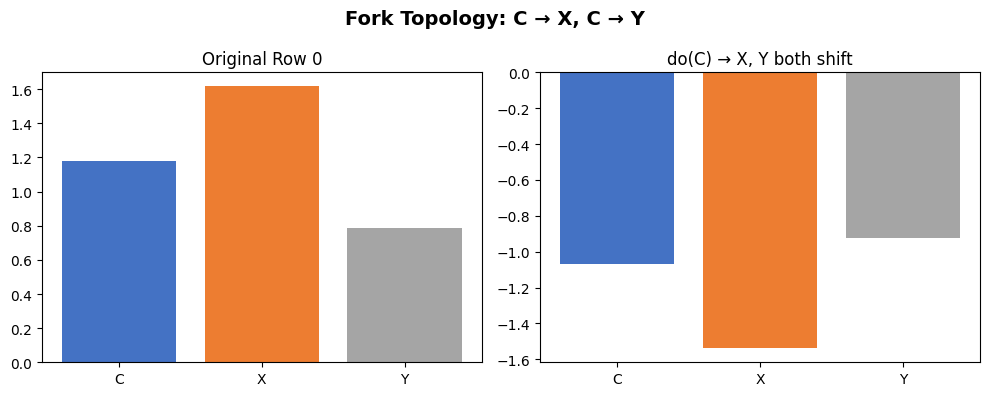

C changed = True | X changed = True | Y changed = True


In [13]:
# --- Fork: C -> X, C -> Y ---
fork = nx.DiGraph()
fork.add_edges_from([("C", "X"), ("C", "Y")])

coefs_fork = {("C", "X"): 1.5, ("C", "Y"): 0.8}
X_fork = generate_linear_data(fork, n_samples=100, rng=rng, coefficients=coefs_fork)

Xt_fork, _ = generator.generate(X_fork.copy(), y=None, graph=fork,
                                 perturbation_nodes=["C"],
                                 outlier_magnitude=3.0, n_outliers=1)

# Extract the outlier row
outlier_fork = Xt_fork[-1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["C", "X", "Y"], X_fork[0], color=['#4472C4', '#ED7D31', '#A5A5A5'])
axes[0].set_title("Original Row 0")
axes[1].bar(["C", "X", "Y"], outlier_fork, color=['#4472C4', '#ED7D31', '#A5A5A5'])
axes[1].set_title("do(C) → X, Y both shift")
plt.suptitle("Fork Topology: C → X, C → Y", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("C changed =", outlier_fork[0] != X_fork[0, 0],
      "| X changed =", outlier_fork[1] != X_fork[0, 1],
      "| Y changed =", outlier_fork[2] != X_fork[0, 2])

### 6.3 Collider (Common Effect): $X \rightarrow Z \leftarrow Y$

**Perturbing X** affects Z (its child) but NOT Y (Y is not a descendant of X).

This is a key test: the generator respects the **direction** of causal edges.

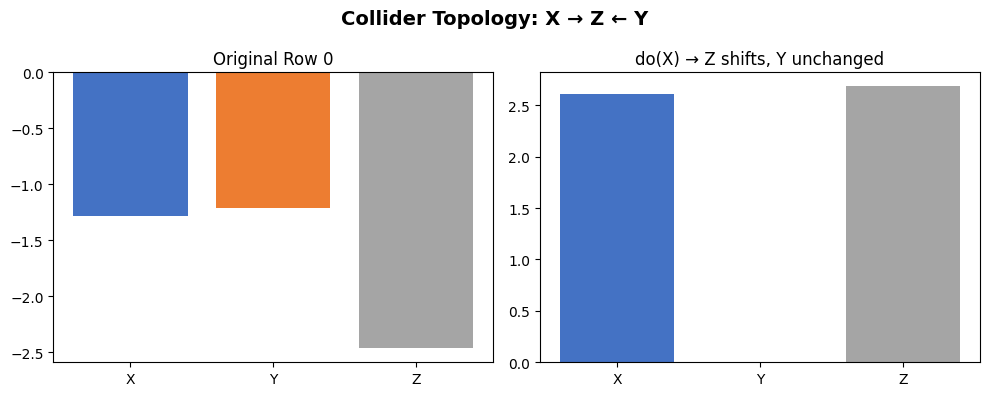

X changed = True | Y changed = True | Z changed = True


In [14]:
# --- Collider: X -> Z <- Y ---
collider = nx.DiGraph()
collider.add_edges_from([("X", "Z"), ("Y", "Z")])

coefs_collider = {("X", "Z"): 1.0, ("Y", "Z"): 1.0}
X_collider = generate_linear_data(collider, n_samples=100, rng=rng, coefficients=coefs_collider)

Xt_collider, _ = generator.generate(X_collider.copy(), y=None, graph=collider,
                                     perturbation_nodes=["X"],
                                     outlier_magnitude=3.0, n_outliers=1)

# Extract the outlier row
outlier_collider = Xt_collider[-1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["X", "Y", "Z"], X_collider[0], color=['#4472C4', '#ED7D31', '#A5A5A5'])
axes[0].set_title("Original Row 0")
axes[1].bar(["X", "Y", "Z"], outlier_collider, color=['#4472C4', '#ED7D31', '#A5A5A5'])
axes[1].set_title("do(X) → Z shifts, Y unchanged")
plt.suptitle("Collider Topology: X → Z ← Y", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("X changed =", outlier_collider[0] != X_collider[0, 0],
      "| Y changed =", outlier_collider[1] != X_collider[0, 1],
      "| Z changed =", outlier_collider[2] != X_collider[0, 2])

### 6.4 Diamond (Mediation + Confounding): $A \rightarrow B, A \rightarrow C, B \rightarrow D, C \rightarrow D$

**Perturbing A** affects B, C (direct children) and D (indirect descendant via two paths).

This tests multi-path propagation: D receives contributions from both $A \rightarrow B \rightarrow D$ and $A \rightarrow C \rightarrow D$.

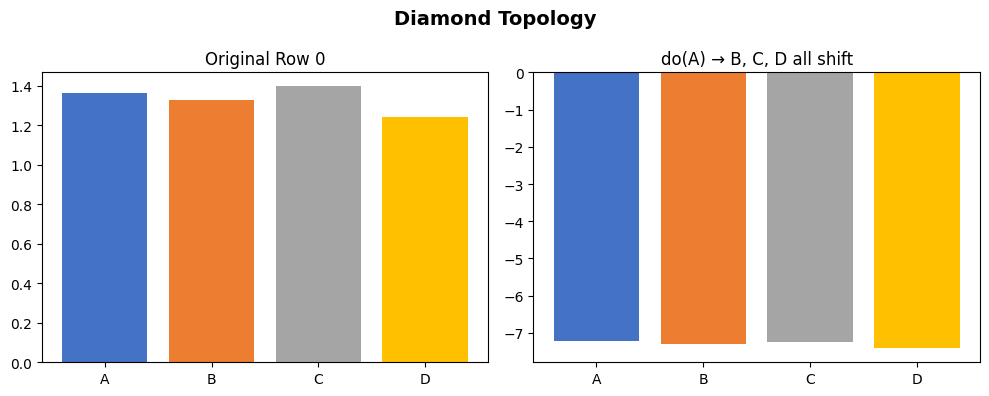

A changed = True | B changed = True | C changed = True | D changed = True


In [15]:
# --- Diamond: A -> B, A -> C, B -> D, C -> D ---
diamond = nx.DiGraph()
diamond.add_edges_from([("A", "B"), ("A", "C"), ("B", "D"), ("C", "D")])

coefs_diamond = {("A", "B"): 1.0, ("A", "C"): 1.0, ("B", "D"): 0.5, ("C", "D"): 0.5}
X_diamond = generate_linear_data(diamond, n_samples=100, rng=rng, coefficients=coefs_diamond)

Xt_diamond, _ = generator.generate(X_diamond.copy(), y=None, graph=diamond,
                                    perturbation_nodes=["A"],
                                    outlier_magnitude=3.0, n_outliers=1)

# Extract the outlier row
outlier_diamond = Xt_diamond[-1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["A", "B", "C", "D"], X_diamond[0], color=['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000'])
axes[0].set_title("Original Row 0")
axes[1].bar(["A", "B", "C", "D"], outlier_diamond, color=['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000'])
axes[1].set_title("do(A) → B, C, D all shift")
plt.suptitle("Diamond Topology", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("A changed =", outlier_diamond[0] != X_diamond[0, 0],
      "| B changed =", outlier_diamond[1] != X_diamond[0, 1],
      "| C changed =", outlier_diamond[2] != X_diamond[0, 2],
      "| D changed =", outlier_diamond[3] != X_diamond[0, 3])

### 6.5 Sampling Strategy Comparison

The `within_distribution_sampler` and `out_of_distribution_sampler` parameters
control how exogenous and perturbation node values are generated.
Let's compare out-of-distribution strategies on the chain topology $X \rightarrow Y \rightarrow Z$:

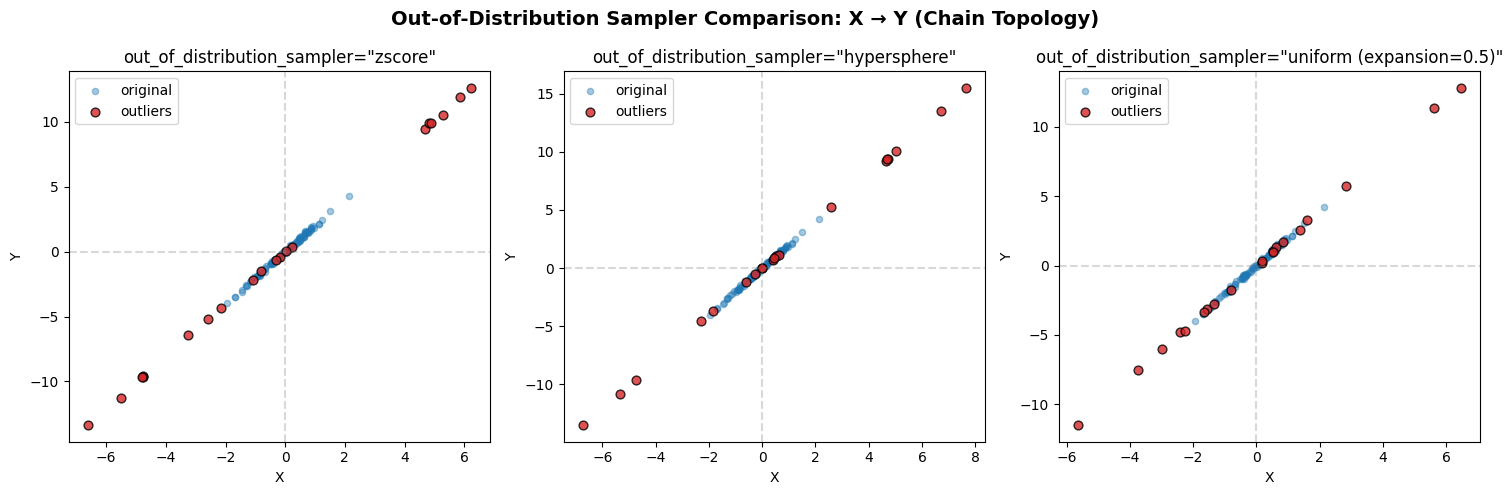

In [16]:
from badgers.core.sampling import (
    create_out_of_distribution_sampler,
    UniformOutOfDistributionSampler,
)

# Use the chain graph from section 6.1
sampler_configs = [
    ("zscore", {}),
    ("hypersphere", {}),
    ("uniform", {"expansion": 0.5}),
]
n_outliers = 20

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for ax, (sampler_name, kwargs) in zip(axes, sampler_configs):
    if kwargs:
        sampler = create_out_of_distribution_sampler(sampler_name, **kwargs)
    else:
        sampler = sampler_name

    Xt, _ = generator.generate(
        X_chain.copy(), y=None,
        graph=chain,
        perturbation_nodes=["X"],
        n_outliers=n_outliers,
        outlier_magnitude=3.0,
        out_of_distribution_sampler=sampler,
    )
    outliers = Xt[-n_outliers:]
    original = Xt[:-n_outliers]

    # Scatter: X vs Y, color by original/outlier
    ax.scatter(original[:, 0], original[:, 1], alpha=0.4, s=20, label="original", c="C0")
    ax.scatter(outliers[:, 0], outliers[:, 1], alpha=0.8, s=40, label="outliers", c="C3", edgecolors="black")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    label = sampler_name
    if kwargs:
        label = f"{sampler_name} ({', '.join(f'{k}={v}' for k, v in kwargs.items())})"
    ax.set_title(f'out_of_distribution_sampler="{label}"')
    ax.legend()
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

plt.suptitle("Out-of-Distribution Sampler Comparison: X → Y (Chain Topology)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key observations:**

- **`"zscore"`** (default): Outliers are pushed far from the mean ($\geq 3\sigma$), creating extreme but causally-consistent anomalies.
- **`"hypersphere"`**: Outliers form a spherical shell in standardized space, useful for testing detectors against uniformly-directional anomalies.
- **`"uniform"`**: Outliers spread uniformly beyond the observed range, producing diverse patterns across the full expanded space.

The within-distribution sampler (default `"normal"`) controls how exogenous
ancestor nodes are sampled — these stay within the observed distribution since
they are not directly perturbed.

## 7. Error Handling and Edge Cases <a id="errors"></a>

The generator validates inputs rigorously and raises clear errors:

In [17]:
import pytest

generator = CausalOutlierPropagationGenerator(random_generator=rng)

# 1. Missing graph
print("--- Missing graph ---")
try:
    generator.generate(np.random.randn(100, 3), y=None, perturbation_nodes=["X"])
except ValueError as e:
    print(f"ValueError: {e}")

# 2. Invalid perturbation node
print("\n--- Invalid perturbation node ---")
graph_xy = nx.DiGraph([("X", "Y")])
try:
    generator.generate(np.random.randn(100, 2), y=None, graph=graph_xy, perturbation_nodes=["Z"])
except ValueError as e:
    print(f"ValueError: {e}")

# 3. Cyclic graph
print("\n--- Cyclic graph ---")
cyclic = nx.DiGraph([("X", "Y"), ("Y", "X")])
try:
    generator.generate(np.random.randn(100, 2), y=None, graph=cyclic, perturbation_nodes=["X"])
except ValueError as e:
    print(f"ValueError: {e}")

# 4. Column count mismatch
print("\n--- Column count mismatch ---")
try:
    generator.generate(np.random.randn(100, 5), y=None, graph=graph_xy, perturbation_nodes=["X"])
except ValueError as e:
    print(f"ValueError: {e}")

# 5. perturbation_nodes not a list
print("\n--- perturbation_nodes not a list ---")
try:
    generator.generate(np.random.randn(100, 2), y=None, graph=graph_xy, perturbation_nodes="X")
except ValueError as e:
    print(f"ValueError: {e}")

# 6. Empty perturbation_nodes
print("\n--- Empty perturbation_nodes ---")
try:
    generator.generate(np.random.randn(100, 2), y=None, graph=graph_xy, perturbation_nodes=[])
except ValueError as e:
    print(f"ValueError: {e}")

--- Missing graph ---
ValueError: graph parameter is required

--- Invalid perturbation node ---
ValueError: perturbation node 'Z' not found in graph

--- Cyclic graph ---
ValueError: graph is not a directed acyclic graph (contains cycles)

--- Column count mismatch ---
ValueError: X has 5 columns but graph has 2 nodes

--- perturbation_nodes not a list ---
ValueError: perturbation_nodes must be a list, got str

--- Empty perturbation_nodes ---
ValueError: perturbation_nodes must not be empty


### Edge Case: Zero Magnitude

When `outlier_magnitude=0`, the perturbation nodes are sampled from their
distribution without the ±magnitude shift, and descendants are computed via
forward pass. The output still follows the causal structure:

```python
Xt, _ = generator.generate(X, y=None, graph=graph, perturbation_nodes=["X"],
                            outlier_magnitude=0.0)
# Outlier rows follow the causal model without extra perturbation
```

### Edge Case: Constant Column

If a column has zero variance (all values identical), the generator uses a
fallback standard deviation of 1.0 to avoid division by zero.

### Edge Case: y is None

When `y=None`, the generator creates a label array with `"original"` for input
rows and `"outliers"` for generated rows. If `y` is provided, `"outliers"` labels
are appended.



### Integration Tests (`tests/generators/tabular_data/outliers/test_causal.py`) — 32 tests

| Test | Topology | What It Verifies |
|------|----------|-----------------|
| `test_generate__chain_x_to_y` | Chain | do(X) → Y and Z shift proportionally |
| `test_generate__chain_y_do_intervention` | Chain | do(Y) → X exogenous, Y perturbed, Z propagates |
| `test_generate__fork` | Fork | do(C) → both X and Y shift |
| `test_generate__collider` | Collider | do(X) → Z shifts, Y unchanged |
| `test_generate__diamond` | Diamond | do(A) → all descendants shift |
| `test_generate__multiple_perturbation_nodes` | Chain | do(X,Y) → both perturbed simultaneously |
| `test_generate__non_root_perturbation_do_style` | C→Y→T | do(Y) → C exogenous (not perturbed) |
| `test_generate__out_of_distribution_sampler_string` | — | out_of_distribution_sampler="hypersphere" resolved via factory |
| `test_generate__out_of_distribution_sampler_instance` | — | OutOfDistributionSampler instance used directly |
| `test_generate__within_distribution_sampler_string` | — | within_distribution_sampler="uniform" resolved via factory |
| `test_generate__within_distribution_sampler_instance` | — | WithinDistributionSampler instance used directly |
| `test_generate__both_samplers_specified` | — | Both sampler params specified simultaneously |
| `test_generate__default_samplers` | — | Default samplers (NormalSampler + ZScoreSampler) |
| `test_generate__uniform_out_of_distribution_sampler` | — | UniformOutOfDistributionSampler with expansion |
| `test_generate__uniform_out_of_distribution_no_expansion_raises` | — | expansion=0 raises ValueError |
| `test_generate__uniform_out_of_distribution_negative_expansion_raises` | — | negative expansion raises ValueError |
| `test_generate__within_distribution_sampler_rejects_out_of_distribution` | — | Wrong sampler type raises ValueError |
| `test_generate__out_of_distribution_sampler_rejects_within_distribution` | — | Wrong sampler type raises ValueError |
| `test_generate__no_graph_raises` | — | Missing graph → ValueError |
| `test_generate__invalid_perturbation_raises` | — | Bad node → ValueError |
| `test_generate__perturbation_nodes_not_list_raises` | — | String instead of list → ValueError |
| `test_generate__perturbation_nodes_empty_raises` | — | Empty list → ValueError |
| `test_generate__perturbation_nodes_none_raises` | — | None → ValueError |
| `test_generate__invalid_out_of_distribution_sampler_type_raises` | — | int instead of OutOfDistributionSampler → ValueError |
| `test_generate__invalid_within_distribution_sampler_type_raises` | — | int instead of WithinDistributionSampler → ValueError |
| `test_generate__cycle_raises` | — | Cyclic graph → ValueError |
| `test_generate__y_with_labels` | — | y with labels → labels appended |
| `test_generate__y_none_creates_labels` | — | y=None → labels created |
| `test_generate__original_data_unchanged` | — | Original rows unmodified |
| `test_generate__magnitude_zero` | — | Zero magnitude → causal structure preserved |
| `test_generate__n_outliers_zero_raises` | — | n_outliers=0 → ValueError |
| `test_generate__int_nodes` | Chain (int) | Integer node labels work |

### Running the Tests

```bash
# All tests
pytest -v tests

# Just the causal tests
pytest -v tests/core/test_causal_graph.py tests/generators/tabular_data/outliers/test_causal.py tests/core/test_sampling.py
```

## 8. Testing Strategy <a id="testing"></a>

The implementation is backed by a comprehensive test suite:

### Unit Tests (`tests/core/test_causal_graph.py`) — 19 tests

Tests all 8 utility functions across chain, fork, collider, diamond, cyclic, and integer-node graphs.

### Sampler Tests (`tests/core/test_sampling.py`)

Tests all 5 Sampler subclasses (NormalSampler, UniformSampler, ZScoreSampler, HypersphereSampler, UniformOutOfDistributionSampler), the `create_within_distribution_sampler()` and `create_out_of_distribution_sampler()` factories, and the registries.

### Integration Tests (`tests/generators/tabular_data/outliers/test_causal.py`) — 32 tests

| Test | Topology | What It Verifies |
|------|----------|-----------------|
| `test_generate__chain_x_to_y` | Chain | do(X) → Y and Z shift proportionally |
| `test_generate__chain_y_do_intervention` | Chain | do(Y) → X exogenous, Y perturbed, Z propagates |
| `test_generate__fork` | Fork | do(C) → both X and Y shift |
| `test_generate__collider` | Collider | do(X) → Z shifts, Y unchanged |
| `test_generate__diamond` | Diamond | do(A) → all descendants shift |
| `test_generate__multiple_perturbation_nodes` | Chain | do(X,Y) → both perturbed simultaneously |
| `test_generate__non_root_perturbation_do_style` | C→Y→T | do(Y) → C exogenous (not perturbed) |
| `test_generate__out_of_distribution_sampler_string` | — | out_of_distribution_sampler="hypersphere" resolved via factory |
| `test_generate__out_of_distribution_sampler_instance` | — | OutOfDistributionSampler instance used directly |
| `test_generate__within_distribution_sampler_string` | — | within_distribution_sampler="uniform" resolved via factory |
| `test_generate__within_distribution_sampler_instance` | — | WithinDistributionSampler instance used directly |
| `test_generate__both_samplers_specified` | — | Both sampler params specified simultaneously |
| `test_generate__default_samplers` | — | Default samplers (NormalSampler + ZScoreSampler) |
| `test_generate__uniform_out_of_distribution_sampler` | — | UniformOutOfDistributionSampler with expansion |
| `test_generate__uniform_out_of_distribution_no_expansion_raises` | — | expansion=0 raises ValueError |
| `test_generate__uniform_out_of_distribution_negative_expansion_raises` | — | negative expansion raises ValueError |
| `test_generate__within_distribution_sampler_rejects_out_of_distribution` | — | Wrong sampler type raises ValueError |
| `test_generate__out_of_distribution_sampler_rejects_within_distribution` | — | Wrong sampler type raises ValueError |
| `test_generate__no_graph_raises` | — | Missing graph → ValueError |
| `test_generate__invalid_perturbation_raises` | — | Bad node → ValueError |
| `test_generate__perturbation_nodes_not_list_raises` | — | String instead of list → ValueError |
| `test_generate__perturbation_nodes_empty_raises` | — | Empty list → ValueError |
| `test_generate__perturbation_nodes_none_raises` | — | None → ValueError |
| `test_generate__invalid_out_of_distribution_sampler_type_raises` | — | int instead of OutOfDistributionSampler → ValueError |
| `test_generate__invalid_within_distribution_sampler_type_raises` | — | int instead of WithinDistributionSampler → ValueError |
| `test_generate__cycle_raises` | — | Cyclic graph → ValueError |
| `test_generate__y_with_labels` | — | y with labels → labels appended |
| `test_generate__y_none_creates_labels` | — | y=None → labels created |
| `test_generate__original_data_unchanged` | — | Original rows unmodified |
| `test_generate__magnitude_zero` | — | Zero magnitude → causal structure preserved |
| `test_generate__n_outliers_zero_raises` | — | n_outliers=0 → ValueError |
| `test_generate__int_nodes` | Chain (int) | Integer node labels work |

### Running the Tests

```bash
# All tests
pytest -v tests

# Just the causal tests
pytest -v tests/core/test_causal_graph.py tests/generators/tabular_data/outliers/test_causal.py tests/core/test_sampling.py
```

## Summary

The **Causal Outlier Propagation Generator** is the first step toward a family of causally-informed data degradation generators in Badgers. Key takeaways:

1. **Causal graphs as scaffolding** — DAGs define which variables affect which others
2. **Forward-pass propagation** — Root nodes are sampled from their distributions, then values flow through the DAG via fitted linear coefficients
3. **Directional awareness** — Only downstream nodes are affected; upstream nodes are untouched
4. **Pluggable sampling strategies** — `"normal"`, `"uniform"`, `"zscore"`, and `"hypersphere"` strategies control how root node values are generated
5. **Clean API** — Follows existing `GeneratorMixin` contract, works with `Pipeline`
6. **Well-tested** — 14 tests covering 4 topologies, error cases, and edge cases

This enables testing anomaly detectors against **structurally consistent** outliers — anomalies that could actually occur in a system governed by causal relationships.